<a href="https://colab.research.google.com/github/pachterlab/rhopca/blob/main/examples/functional_rhoPCA_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q scikit-fda==0.10.1
!pip install git+https://github.com/pachterlab/rhopca.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.1 MB/s eta 0:00:00
  Cloning https://github.com/pachterlab/rhopca.git to /tmp/pip-req-build-i4yncjox
  Running command git clone --filter=blob:none --quiet https://github.com/pachterlab/rhopca.git /tmp/pip-req-build-i4yncjox
  Resolved https://github.com/pachterlab/rhopca.git to commit 32b507d7da3991e8fc4b03ffe3ec0ff628f941bb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 4.0 MB/s eta 0:00:00
   ━━━

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skfda.datasets import fetch_growth

# repo_root = Path.cwd().resolve()
# if not (repo_root / "src").exists():
#     repo_root = repo_root.parent
# sys.path.insert(0, str(repo_root / "src"))

from rhopca.methods import functionalRhoPCA

In [3]:
# --- Load dataset ---
dataset = fetch_growth()
fd = dataset["data"]
y = np.array(dataset["target"])

boys_mask = y == 0
girls_mask = y == 1

boys_fd = fd[boys_mask]
girls_fd = fd[girls_mask]

ages = np.asarray(fd.grid_points[0], dtype=float)
heights = np.asarray(fd.data_matrix[..., 0], dtype=float)

n_subjects = heights.shape[0]
subject_ids = np.arange(n_subjects)
sex_labels = np.where(y == 0, "boy", "girl")

growth_df = pd.DataFrame(
    {
        "child_id": np.repeat(subject_ids, len(ages)),
        "age": np.tile(ages, n_subjects),
        "height": heights.reshape(-1),
        "sex": np.repeat(sex_labels, len(ages)),
    }
)

growth_df.head()

,child_id,age,height,sex
0,0,1.00,81.3,boy
1,0,1.25,84.2,boy
2,0,1.50,86.4,boy
3,0,1.75,88.9,boy
4,0,2.00,91.4,boy


In [4]:
growth_df.groupby("sex")["child_id"].nunique()

,child_id
sex,
boy,39
girl,54


In [5]:
mdl = functionalRhoPCA(
    growth_df,
    contrast_column="sex",
    target="boy",
    background="girl",
    observation="child_id",
    time="age",
    gene="height",
    basis="bspline",
    num_basis_functions=7,
    n_components=7,
)

mdl.fit()
mdl.eigvals

array([31.42245674,  2.11680709,  1.44470081,  1.057268  ,  0.91377541,
        0.38573437,  0.17841947])

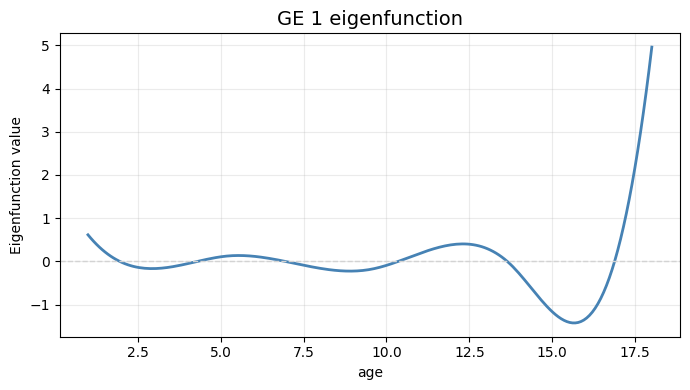

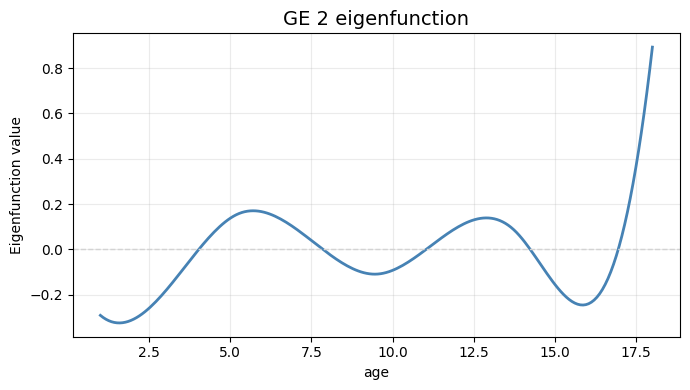

In [6]:

observed_time = np.linspace(
    growth_df["age"].min(),
    growth_df["age"].max(),
    200,
    endpoint=True,
)

mdl.plot(plot_type="eigenfunction", components=1, time_values=observed_time)
mdl.plot(plot_type="eigenfunction", components=2, time_values=observed_time)

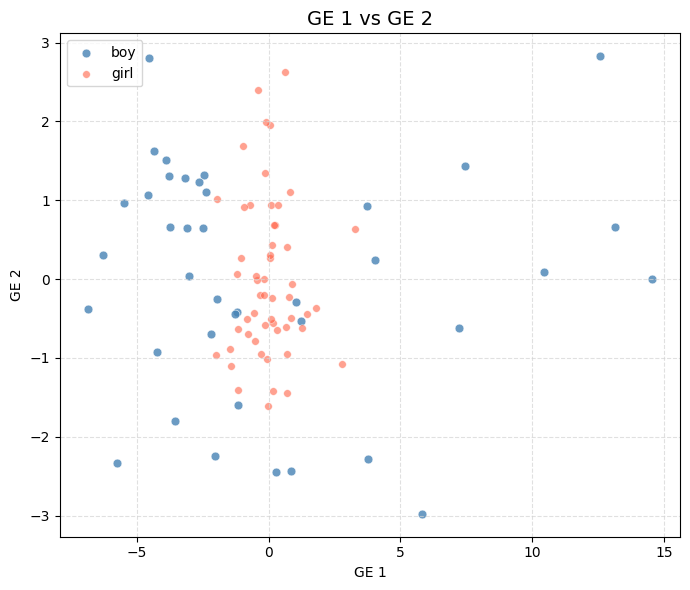

In [7]:
mdl.plot(plot_type="scatter", components=(1, 2))

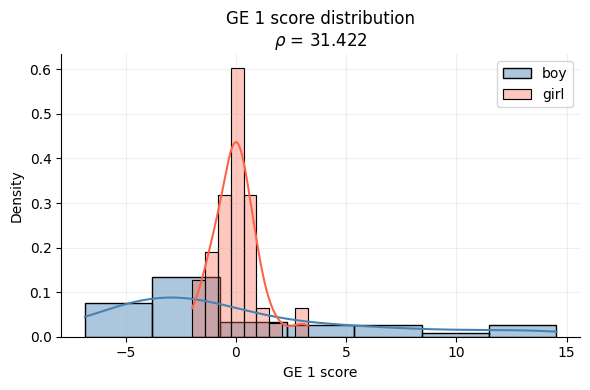

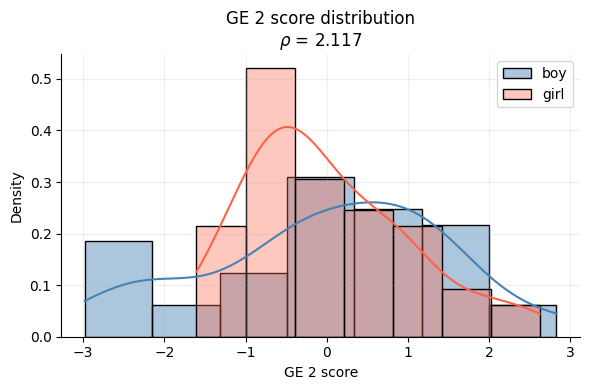

In [8]:
mdl.plot(plot_type="hist", components=1)
mdl.plot(plot_type="hist", components=2)